# A Cricket related simple parallel Langgraph Example

* Calculation of Strike Rate, Boundaries Per Ball and Boundary Percentages 

In [3]:
# Import Libraries
import langgraph 
from langgraph.graph import StateGraph, START, END

from typing import TypedDict, List, Literal, Type, Annotated


In [4]:
# Define the State

class BatsManState(TypedDict):
    runs : int 
    balls : int 
    fours : int 
    sixes : int 

    sr : float 
    bpb : float
    boundary_percentage : float 
    summary : str

In [ ]:
# define nodes 

#calculate_strikeRate

def calculate_strikeRate(state: BatsManState)->dict:
    state['sr'] = round((state['runs'] / state['balls']) * 100, 2)

    # Returning the partial state only to avoid the conflict
    return {'sr' : state['sr']}


#calculate_bpb

def calculate_bpb(state : BatsManState) -> dict:
    state['bpb'] = round(((state['sixes'] + state['fours'])/state['balls']) * 100 ,2)
    
    # Returning the partial state only to avoid the conflict
    return {"bpb": state["bpb"] }

# calculate_boundary_pct

def calculate_boundary_pct(state : BatsManState) -> dict:
    state['boundary_percentage'] = round((( (state["fours"] * 4) + (state['sixes'] * 6) ) / state['runs'] ) * 100 , 2)

    # Returning the partial state only to avoid the conflict
    return {"boundary_percentage": state["boundary_percentage"]}


# summary
def summary(state : BatsManState)-> dict :
    state["summary"] = f""" 
    Strike Rate :- {state['sr']} 
    Boundary Per Ball :- {state['bpb']} 
    Boundary Percentage :- {state['boundary_percentage']}
    """
    return {'summary': state['summary']}

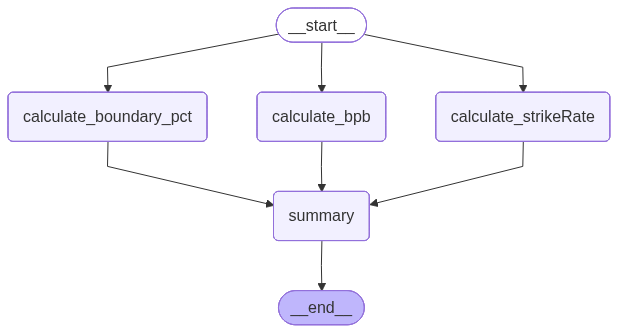

In [21]:
# define graph

graph = StateGraph(BatsManState)

# Add nodes 
graph.add_node('calculate_strikeRate', calculate_strikeRate)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_pct', calculate_boundary_pct)
graph.add_node('summary', summary)

# Add Edges 
graph.add_edge(START, "calculate_strikeRate")
graph.add_edge(START, "calculate_bpb")
graph.add_edge(START, "calculate_boundary_pct")

graph.add_edge("calculate_strikeRate", "summary")
graph.add_edge("calculate_bpb", "summary")
graph.add_edge("calculate_boundary_pct", "summary")

graph.add_edge("summary", END)


# Compile Graphs
workflow = graph.compile()

# see the graph 
workflow

In [23]:
# invoke the Graph 

# initial state 
initial_state =     {"runs": 150, 
    'balls' : 120,
    'fours': 10,
    'sixes': 6}
# Response
response = workflow.invoke( initial_state )


# Final Report
print(response['summary'], end="", flush=True, sep=",")

 
    Strike Rate :- 0.01 
    Boundary Per Ball :- 13.33 
    Boundary Percentage :- 50.67
    